# CKD data preprocessing and exploratory analysis

This notebook completes the **Data preprocessing** assignment using the Chronic Kidney Disease (CKD) dataset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease).

The analysis is reproducible from the local source file in `data/chronic_kidney_disease.csv`. The notebook:

1. loads and describes the source data;
2. selects and renames the required columns;
3. converts hemoglobin from g/dL to g/L and recodes the class;
4. removes rows with three or more missing values;
5. splits affected and control individuals;
6. calculates descriptive statistics and reviews histograms/outliers; and
7. calculates and visualizes a correlation matrix for each group.

**Data citation:** Rubini, L., Soundarapandian, P., & Eswaran, P. (2015). *Chronic Kidney Disease* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5G020 (CC BY 4.0).

## 1. Setup and display options

Only standard data-analysis libraries are used. Pandas provides the data-frame pipeline, while Matplotlib and Seaborn provide the visualizations.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

# This works both when the notebook is launched from its own folder and from
# the parent workspace folder.
DATA_CANDIDATES = [
    Path("data/chronic_kidney_disease.csv"),
    Path("completed_data_preprocessing/data/chronic_kidney_disease.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find data/chronic_kidney_disease.csv. "
        "Run this notebook from the assignment folder or its parent."
    )

DATA_PATH

WindowsPath('data/chronic_kidney_disease.csv')

## 2. Load and describe the original dataset

UCI describes this as a multivariate classification dataset with **400 observations**, **24 features**, one binary target (`class`), and missing values. The target labels are `ckd` and `notckd`. The source file represents missing values as `NaN`.

The fields needed here include age; blood pressure; specific gravity; albumin; sugar; several blood measurements; and class. According to the assignment, the source hemoglobin unit is g/dL; it will be converted to g/L later by multiplying by 10.

In [2]:
raw = pd.read_csv(DATA_PATH)

print(f"Original shape: {raw.shape[0]} rows x {raw.shape[1]} columns")
display(raw.head())
display(
    pd.DataFrame(
        {
            "dtype": raw.dtypes.astype(str),
            "missing": raw.isna().sum(),
            "missing_%": raw.isna().mean().mul(100).round(1),
            "unique_non_missing": raw.nunique(dropna=True),
        }
    )
)

Original shape: 400 rows x 25 columns


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.000,80.000,1.020,1.000,0.000,NaN,normal,notpresent,notpresent,121.000,36.000,1.200,NaN,NaN,15.400,44.000,"7,800.000",5.200,yes,yes,no,good,no,no,ckd
1,7.000,50.000,1.020,4.000,0.000,NaN,normal,notpresent,notpresent,NaN,18.000,0.800,NaN,NaN,11.300,38.000,"6,000.000",NaN,no,no,no,good,no,no,ckd
2,62.000,80.000,1.010,2.000,3.000,normal,normal,notpresent,notpresent,423.000,53.000,1.800,NaN,NaN,9.600,31.000,"7,500.000",NaN,no,yes,no,poor,no,yes,ckd
3,48.000,70.000,1.005,4.000,0.000,normal,abnormal,present,notpresent,117.000,56.000,3.800,111.000,2.500,11.200,32.000,"6,700.000",3.900,yes,no,no,poor,yes,yes,ckd
4,51.000,80.000,1.010,2.000,0.000,normal,normal,notpresent,notpresent,106.000,26.000,1.400,NaN,NaN,11.600,35.000,"7,300.000",4.600,no,no,no,good,no,no,ckd


,dtype,missing,missing_%,unique_non_missing
age,float64,9,2.200,76
bp,float64,12,3.000,10
sg,float64,47,11.800,5
al,float64,46,11.500,6
su,float64,49,12.200,6
rbc,object,152,38.000,2
pc,object,65,16.200,2
pcc,object,4,1.000,2
ba,object,4,1.000,2
bgr,float64,44,11.000,146


## 3. Construct the preprocessing pipeline

The assignment uses full, readable column names, while the source uses abbreviations. The mapping below selects **exactly** the 14 requested columns and renames them.

The pipeline also:

- coerces the 13 measurement columns to numeric values (invalid text would become missing);
- strips whitespace from the source class values (the raw file contains both `ckd` and `ckd\t`);
- maps `ckd` to `a` (affected) and `notckd` to `c` (control);
- multiplies hemoglobin by 10 to convert g/dL to g/L; and
- keeps only rows containing fewer than three missing values across the selected 14 columns.

In [3]:
COLUMN_MAP = {
    "age": "age",
    "bp": "blood pressure",
    "sg": "specific gravity",
    "al": "albumin",
    "su": "sugar",
    "bgr": "blood glucose random",
    "bu": "blood urea",
    "sod": "sodium",
    "pot": "potassium",
    "hemo": "hemoglobin",
    "pcv": "packed cell volume",
    "wbcc": "white blood cell count",
    "rbcc": "red blood cell count",
    "class": "class",
}

NUMERIC_COLUMNS = [name for name in COLUMN_MAP.values() if name != "class"]


def preprocess_ckd(frame: pd.DataFrame):
    '''Return the assignment-ready frame and a row-level cleaning audit.'''
    prepared = frame.loc[:, list(COLUMN_MAP)].rename(columns=COLUMN_MAP).copy()
    prepared[NUMERIC_COLUMNS] = prepared[NUMERIC_COLUMNS].apply(
        pd.to_numeric, errors="coerce"
    )
    prepared["class"] = (
        prepared["class"]
        .astype("string")
        .str.strip()
        .map({"ckd": "a", "notckd": "c"})
    )
    prepared["hemoglobin"] = prepared["hemoglobin"] * 10

    missing_count = prepared.isna().sum(axis=1)
    audit = pd.DataFrame(
        {
            "missing_values": missing_count,
            "kept": missing_count < 3,
        },
        index=prepared.index,
    )
    cleaned = prepared.loc[audit["kept"]].copy()
    return cleaned, audit


ckd, cleaning_audit = preprocess_ckd(raw)

assert ckd.columns.tolist() == list(COLUMN_MAP.values())
assert ckd.shape[1] == 14
assert set(ckd["class"].dropna().unique()) == {"a", "c"}
assert ckd.isna().sum(axis=1).lt(3).all()

print("Rows by number of missing values before filtering:")
display(
    cleaning_audit["missing_values"]
    .value_counts()
    .sort_index()
    .rename_axis("missing values in selected columns")
    .to_frame("rows")
)
print(f"Rows removed (3 or more missing values): {(~cleaning_audit['kept']).sum()}")
print(f"Rows left in the modified data frame: {len(ckd)}")

Rows by number of missing values before filtering:


,rows
missing values in selected columns,
0,203
1,18
2,44
3,33
4,41
5,21
6,13
7,14
8,6


Rows removed (3 or more missing values): 135
Rows left in the modified data frame: 265


In [4]:
print("Missing values remaining by column (one or two per retained row are allowed):")
display(ckd.isna().sum().to_frame("missing"))

print("Modified data frame:")
display(ckd)

Missing values remaining by column (one or two per retained row are allowed):


,missing
age,3
blood pressure,3
specific gravity,1
albumin,0
sugar,0
blood glucose random,10
blood urea,5
sodium,21
potassium,21
hemoglobin,3


Modified data frame:


,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
0,48.000,80.000,1.020,1.000,0.000,121.000,36.000,NaN,NaN,154.000,44.000,"7,800.000",5.200,a
3,48.000,70.000,1.005,4.000,0.000,117.000,56.000,111.000,2.500,112.000,32.000,"6,700.000",3.900,a
4,51.000,80.000,1.010,2.000,0.000,106.000,26.000,NaN,NaN,116.000,35.000,"7,300.000",4.600,a
5,60.000,90.000,1.015,3.000,0.000,74.000,25.000,142.000,3.200,122.000,39.000,"7,800.000",4.400,a
6,68.000,70.000,1.010,0.000,0.000,100.000,54.000,104.000,4.000,124.000,36.000,NaN,NaN,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.000,80.000,1.020,0.000,0.000,140.000,49.000,150.000,4.900,157.000,47.000,"6,700.000",4.900,c
396,42.000,70.000,1.025,0.000,0.000,75.000,31.000,141.000,3.500,165.000,54.000,"7,800.000",6.200,c
397,12.000,80.000,1.020,0.000,0.000,100.000,26.000,137.000,4.400,158.000,49.000,"6,600.000",5.400,c
398,17.000,60.000,1.025,0.000,0.000,114.000,50.000,135.000,4.900,142.000,51.000,"7,200.000",5.900,c


### Cleaning result

The rule removes **135 rows** and leaves **265 rows**. Missing values are not otherwise imputed because the assignment asks only to remove rows with three or more missing values. Retaining the remaining missing values also avoids inventing measurements before group-level exploration; Pandas' descriptive statistics and pairwise correlations ignore them where appropriate.

## 4. Split affected and control individuals

`a` means affected (original class `ckd`) and `c` means control (original class `notckd`). Each displayed data frame includes the same 14 required columns.

In [5]:
affected = ckd.loc[ckd["class"].eq("a")].copy()
control = ckd.loc[ckd["class"].eq("c")].copy()

assert len(affected) + len(control) == len(ckd)

print(f"Affected individuals: {len(affected)} rows")
display(affected)

print(f"Control individuals: {len(control)} rows")
display(control)

Affected individuals: 126 rows


,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
0,48.000,80.000,1.020,1.000,0.000,121.000,36.000,NaN,NaN,154.000,44.000,"7,800.000",5.200,a
3,48.000,70.000,1.005,4.000,0.000,117.000,56.000,111.000,2.500,112.000,32.000,"6,700.000",3.900,a
4,51.000,80.000,1.010,2.000,0.000,106.000,26.000,NaN,NaN,116.000,35.000,"7,300.000",4.600,a
5,60.000,90.000,1.015,3.000,0.000,74.000,25.000,142.000,3.200,122.000,39.000,"7,800.000",4.400,a
6,68.000,70.000,1.010,0.000,0.000,100.000,54.000,104.000,4.000,124.000,36.000,NaN,NaN,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,62.000,90.000,1.020,2.000,1.000,169.000,48.000,138.000,2.900,134.000,47.000,"11,000.000",6.100,a
244,64.000,90.000,1.015,3.000,2.000,463.000,64.000,135.000,4.100,122.000,40.000,"9,800.000",4.600,a
246,48.000,110.000,1.015,3.000,0.000,106.000,215.000,120.000,5.700,86.000,26.000,"5,000.000",2.500,a
248,59.000,70.000,1.010,1.000,3.000,424.000,55.000,138.000,4.500,126.000,37.000,"10,200.000",4.100,a


Control individuals: 139 rows


,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
250,40.000,80.000,1.025,0.000,0.000,140.000,10.000,135.000,5.000,150.000,48.000,"10,400.000",4.500,c
251,23.000,80.000,1.025,0.000,0.000,70.000,36.000,150.000,4.600,170.000,52.000,"9,800.000",5.000,c
252,45.000,80.000,1.025,0.000,0.000,82.000,49.000,147.000,4.400,159.000,46.000,"9,100.000",4.700,c
253,57.000,80.000,1.025,0.000,0.000,119.000,17.000,135.000,4.700,154.000,42.000,"6,200.000",6.200,c
254,51.000,60.000,1.025,0.000,0.000,99.000,38.000,135.000,3.700,130.000,49.000,"8,300.000",5.200,c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.000,80.000,1.020,0.000,0.000,140.000,49.000,150.000,4.900,157.000,47.000,"6,700.000",4.900,c
396,42.000,70.000,1.025,0.000,0.000,75.000,31.000,141.000,3.500,165.000,54.000,"7,800.000",6.200,c
397,12.000,80.000,1.020,0.000,0.000,100.000,26.000,137.000,4.400,158.000,49.000,"6,600.000",5.400,c
398,17.000,60.000,1.025,0.000,0.000,114.000,50.000,135.000,4.900,142.000,51.000,"7,200.000",5.900,c


### Split result

- **Affected:** 126 rows
- **Control:** 139 rows

The split is fairly balanced after applying the missing-value rule.

## 5. Basic statistics

The tables report count, mean, standard deviation, minimum, quartiles, and maximum for every numerical column. The class column is constant within each split by construction, so its frequency is shown separately.

In [6]:
def show_basic_statistics(frame: pd.DataFrame, group_name: str):
    print(f"{group_name}: numerical statistics")
    display(frame[NUMERIC_COLUMNS].describe().T)
    print(f"{group_name}: class statistics")
    display(frame[["class"]].describe().T)


show_basic_statistics(affected, "Affected")
show_basic_statistics(control, "Control")

Affected: numerical statistics


,count,mean,std,min,25%,50%,75%,max
age,123.000,57.081,14.465,6.000,49.500,60.000,65.000,90.000
blood pressure,125.000,80.720,15.769,50.000,70.000,80.000,90.000,180.000
specific gravity,125.000,1.014,0.005,1.005,1.010,1.015,1.015,1.025
albumin,126.000,1.849,1.437,0.000,0.250,2.000,3.000,5.000
sugar,126.000,0.810,1.367,0.000,0.000,0.000,1.000,5.000
blood glucose random,120.000,181.200,93.549,22.000,107.000,158.000,241.250,490.000
blood urea,125.000,80.420,60.501,1.500,37.000,60.000,107.000,322.000
sodium,108.000,133.731,7.667,104.000,131.750,136.000,139.000,145.000
potassium,108.000,4.752,4.204,2.500,3.800,4.200,4.900,47.000
hemoglobin,125.000,106.432,21.897,31.000,95.000,108.000,120.000,161.000


Affected: class statistics


,count,unique,top,freq
class,126,1,a,126


Control: numerical statistics


,count,mean,std,min,25%,50%,75%,max
age,139.000,46.568,15.904,12.000,34.000,46.000,58.000,80.000
blood pressure,137.000,71.314,8.559,60.000,60.000,70.000,80.000,80.000
specific gravity,139.000,1.022,0.003,1.020,1.020,1.020,1.025,1.025
albumin,139.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
sugar,139.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
blood glucose random,135.000,107.385,18.748,70.000,93.000,107.000,123.500,140.000
blood urea,135.000,32.874,11.482,10.000,23.500,33.000,44.000,50.000
sodium,136.000,141.735,4.792,135.000,138.000,141.000,146.000,150.000
potassium,136.000,4.335,0.596,3.300,3.700,4.500,4.900,5.000
hemoglobin,137.000,151.883,12.845,130.000,141.000,150.000,162.000,178.000


Control: class statistics


,count,unique,top,freq
class,139,1,c,139


### Statistical comparison

The affected group is visibly more heterogeneous. It has lower central values for specific gravity, hemoglobin, packed cell volume, and red blood cell count, while blood glucose and blood urea are higher and more variable. These are descriptive associations only; they do not establish causal effects, and the retained missing values mean that column counts differ slightly.

## 6. Histograms and outlier review

All 13 retained measurement columns are numeric and are plotted below. Each subplot uses its own horizontal scale, and missing observations are automatically omitted. Albumin and sugar are ordinal test grades, and specific gravity takes a small fixed set of values, so their histogram shapes should not be read as continuous bell-shaped distributions.

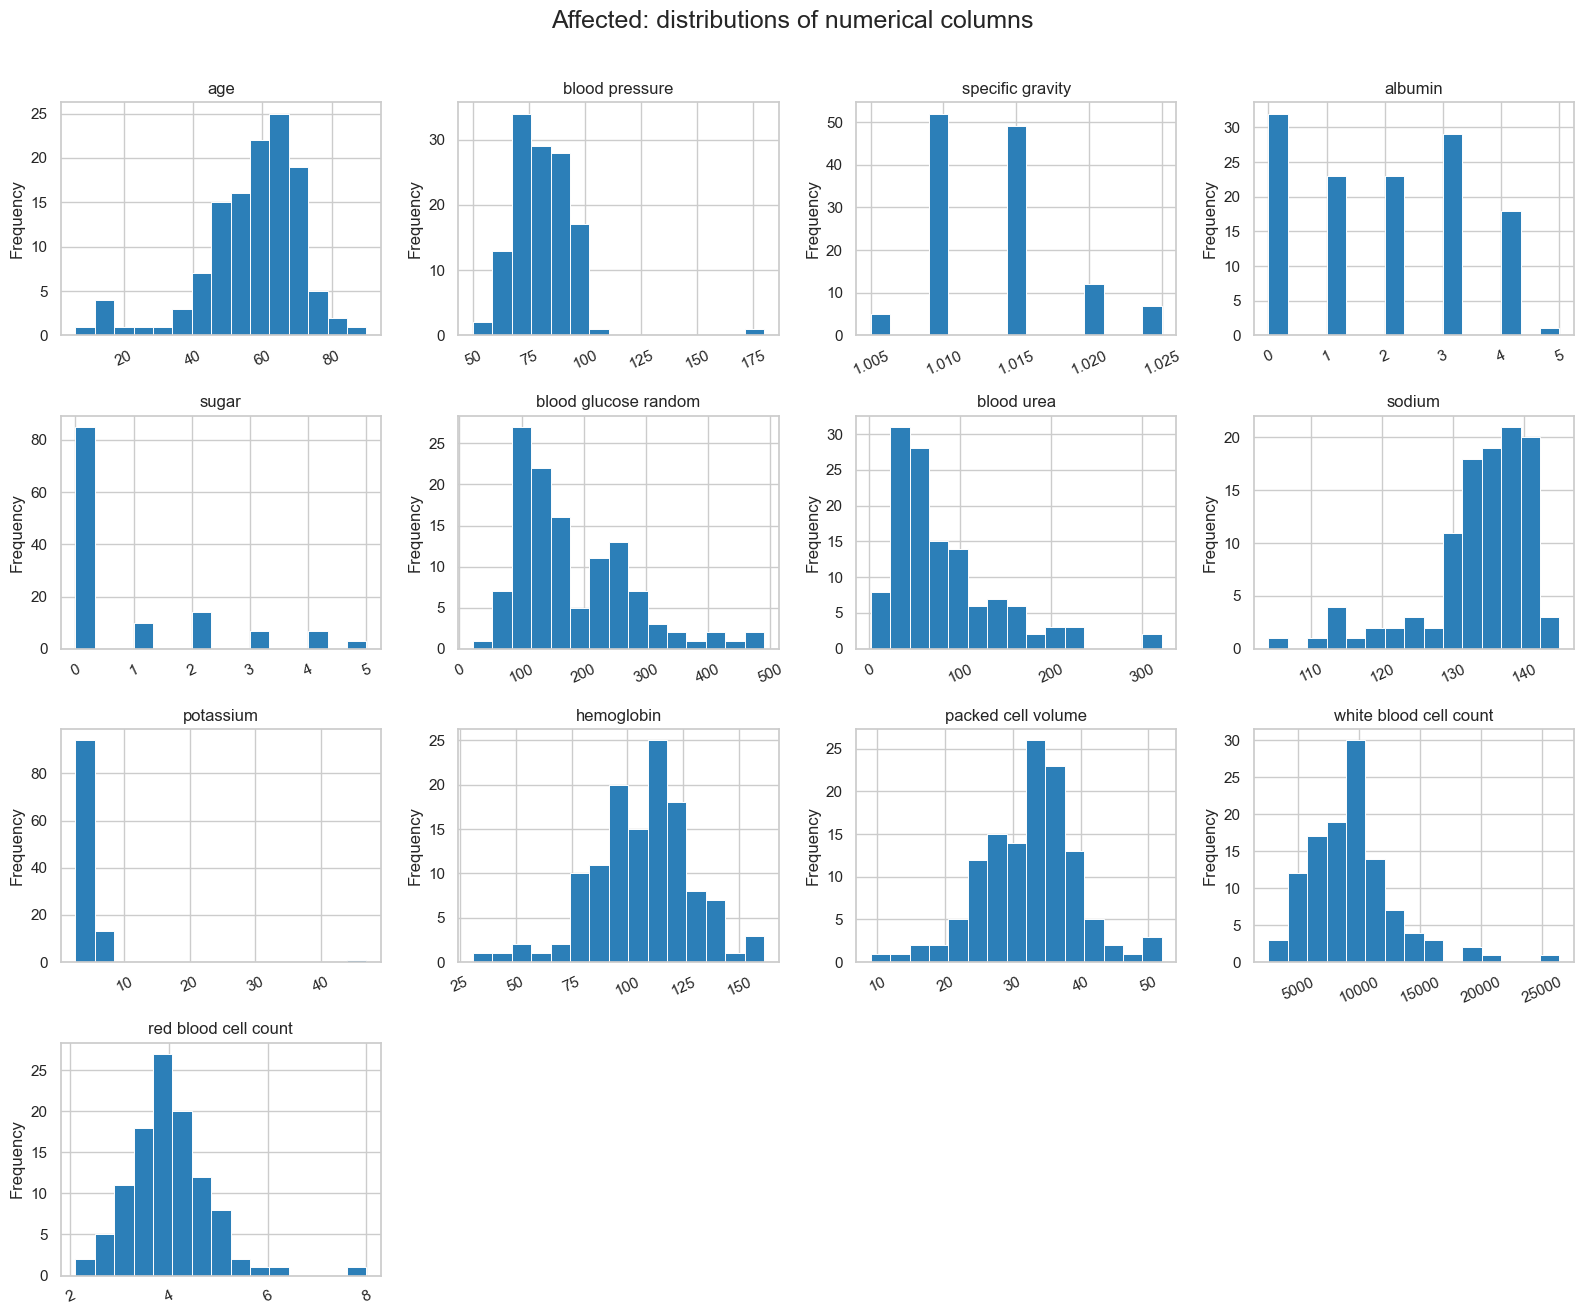

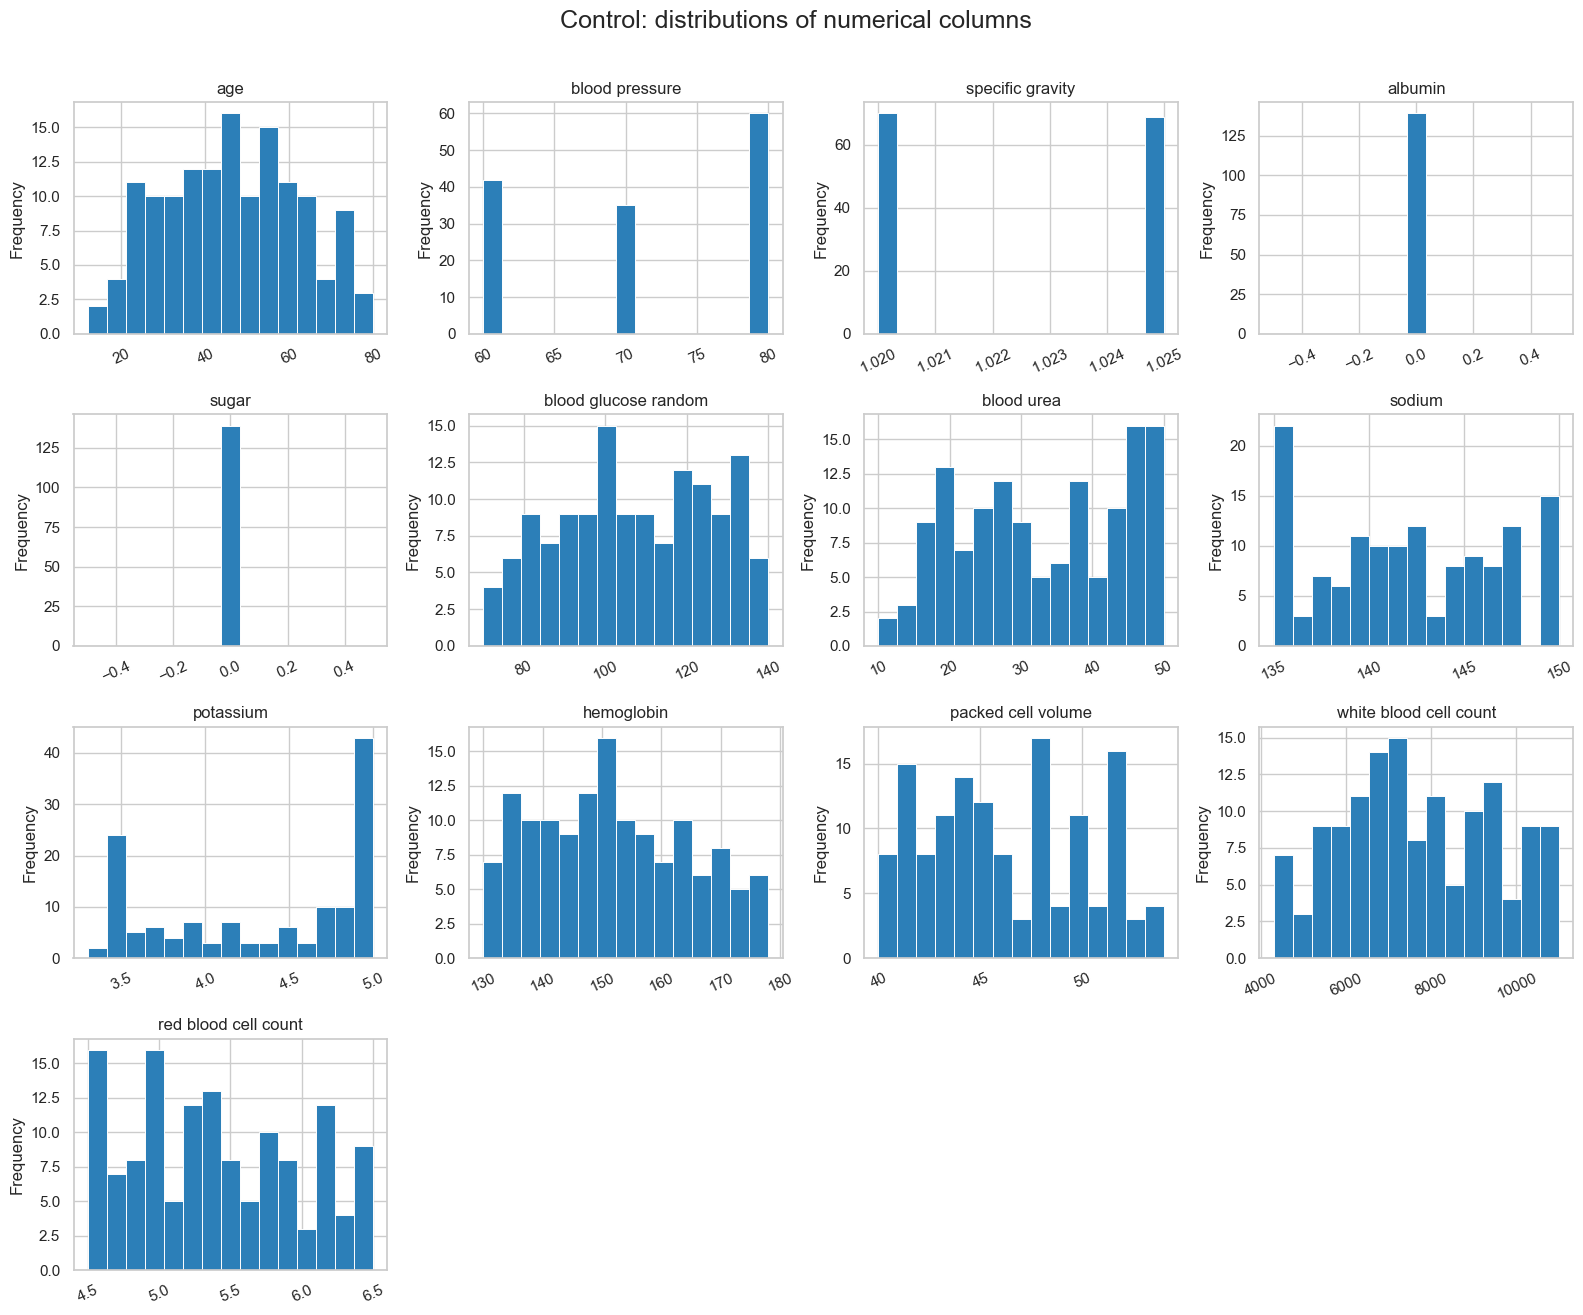

In [7]:
def plot_histograms(frame: pd.DataFrame, group_name: str):
    axes = frame[NUMERIC_COLUMNS].hist(
        bins=15,
        figsize=(16, 13),
        layout=(4, 4),
        color="#2C7FB8",
        edgecolor="white",
        linewidth=0.7,
    )
    axes = np.asarray(axes).ravel()
    for ax in axes:
        ax.set_ylabel("Frequency")
        ax.tick_params(axis="x", rotation=25)
    for ax in axes[len(NUMERIC_COLUMNS):]:
        ax.set_visible(False)
    plt.suptitle(f"{group_name}: distributions of numerical columns", fontsize=18, y=1.01)
    plt.tight_layout()
    plt.show()


plot_histograms(affected, "Affected")
plot_histograms(control, "Control")

### IQR outlier screen

To make the visual review reproducible, the next table applies the common 1.5 × IQR rule separately within each group. This is a **screening rule**, not an automatic deletion rule. It is especially limited for discrete variables such as albumin, sugar, and specific gravity.

In [8]:
def iqr_outlier_summary(frame: pd.DataFrame) -> pd.DataFrame:
    q1 = frame[NUMERIC_COLUMNS].quantile(0.25)
    q3 = frame[NUMERIC_COLUMNS].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flagged = frame[NUMERIC_COLUMNS].lt(lower) | frame[NUMERIC_COLUMNS].gt(upper)
    return pd.DataFrame(
        {
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower fence": lower,
            "upper fence": upper,
            "flagged values": flagged.sum(),
        }
    )


print("Affected: IQR outlier screen")
affected_outliers = iqr_outlier_summary(affected)
display(affected_outliers)

print("Control: IQR outlier screen")
control_outliers = iqr_outlier_summary(control)
display(control_outliers)

Affected: IQR outlier screen


,Q1,Q3,IQR,lower fence,upper fence,flagged values
age,49.500,65.000,15.500,26.250,88.250,8
blood pressure,70.000,90.000,20.000,40.000,120.000,1
specific gravity,1.010,1.015,0.005,1.003,1.022,7
albumin,0.250,3.000,2.750,-3.875,7.125,0
sugar,0.000,1.000,1.000,-1.500,2.500,17
blood glucose random,107.000,241.250,134.250,-94.375,442.625,3
blood urea,37.000,107.000,70.000,-68.000,212.000,6
sodium,131.750,139.000,7.250,120.875,149.875,9
potassium,3.800,4.900,1.100,2.150,6.550,2
hemoglobin,95.000,120.000,25.000,57.500,157.500,5


Control: IQR outlier screen


,Q1,Q3,IQR,lower fence,upper fence,flagged values
age,34.000,58.000,24.000,-2.000,94.000,0
blood pressure,60.000,80.000,20.000,30.000,110.000,0
specific gravity,1.020,1.025,0.005,1.013,1.032,0
albumin,0.000,0.000,0.000,0.000,0.000,0
sugar,0.000,0.000,0.000,0.000,0.000,0
blood glucose random,93.000,123.500,30.500,47.250,169.250,0
blood urea,23.500,44.000,20.500,-7.250,74.750,0
sodium,138.000,146.000,8.000,126.000,158.000,0
potassium,3.700,4.900,1.200,1.900,6.700,0
hemoglobin,141.000,162.000,21.000,109.500,193.500,0


### Outlier interpretation and handling

The affected histograms show clear right tails for blood glucose random and blood urea, plus a few unusually low or high values in measurements such as sodium, hemoglobin, packed cell volume, and cell counts. The IQR screen also flags several affected observations. The control group is much tighter and has no values beyond its group-specific 1.5 × IQR fences.

I would **not remove the affected values automatically**: extreme laboratory measurements may be genuine manifestations of kidney disease, and deleting them could erase clinically important cases. A suitable handling sequence would be:

1. check the source record, unit, and plausible physiological range;
2. correct or mark as missing only values shown to be data-entry errors;
3. retain plausible extremes for this descriptive analysis; and
4. for a later model sensitive to scale, consider robust scaling, a log transform for strongly right-skewed positive variables, or winsorization documented as a sensitivity analysis.

## 7. Correlation matrices

Pearson correlations are calculated separately for affected and control individuals. Pandas uses pairwise complete observations, so each coefficient uses the rows where both variables are present. Correlations involving the discrete albumin, sugar, and specific-gravity fields should be interpreted cautiously.

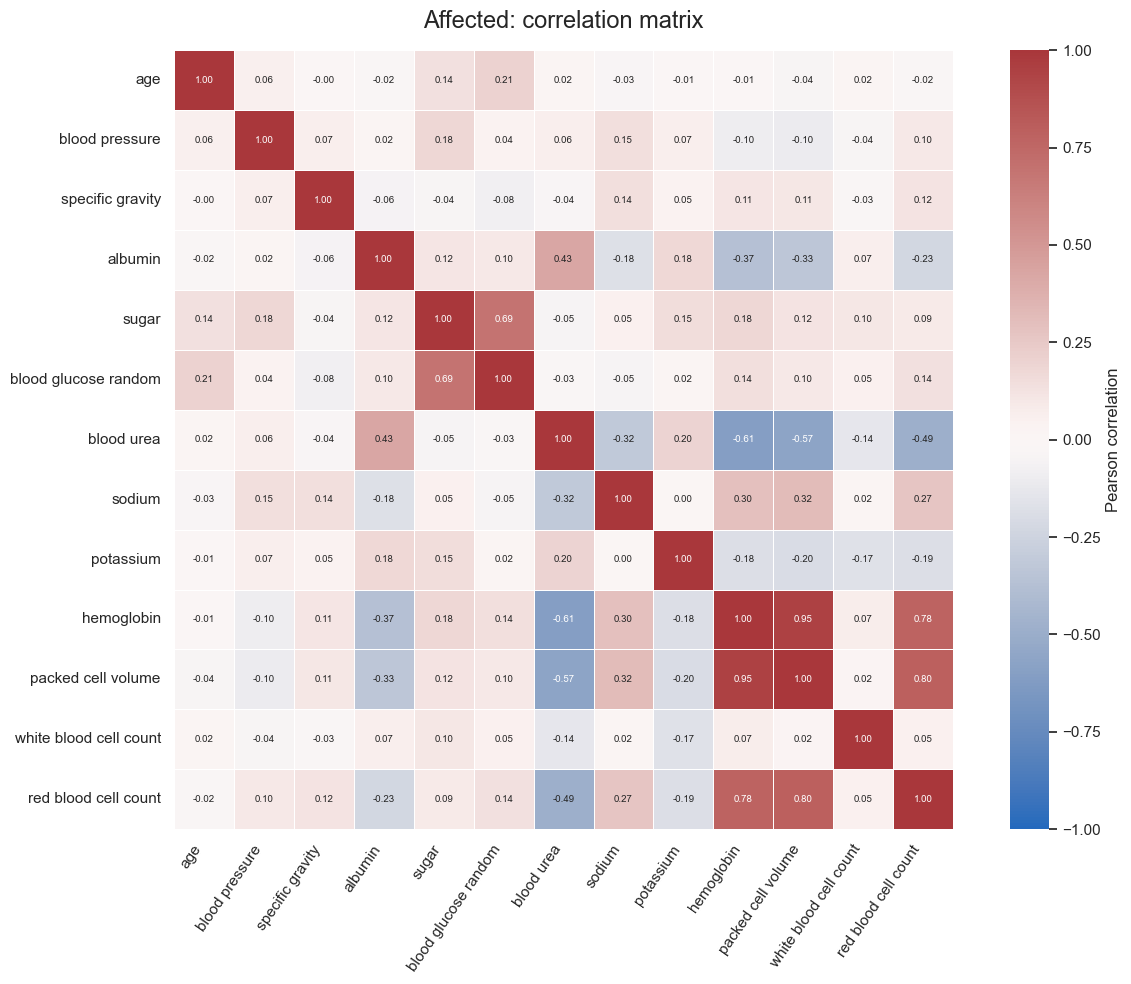

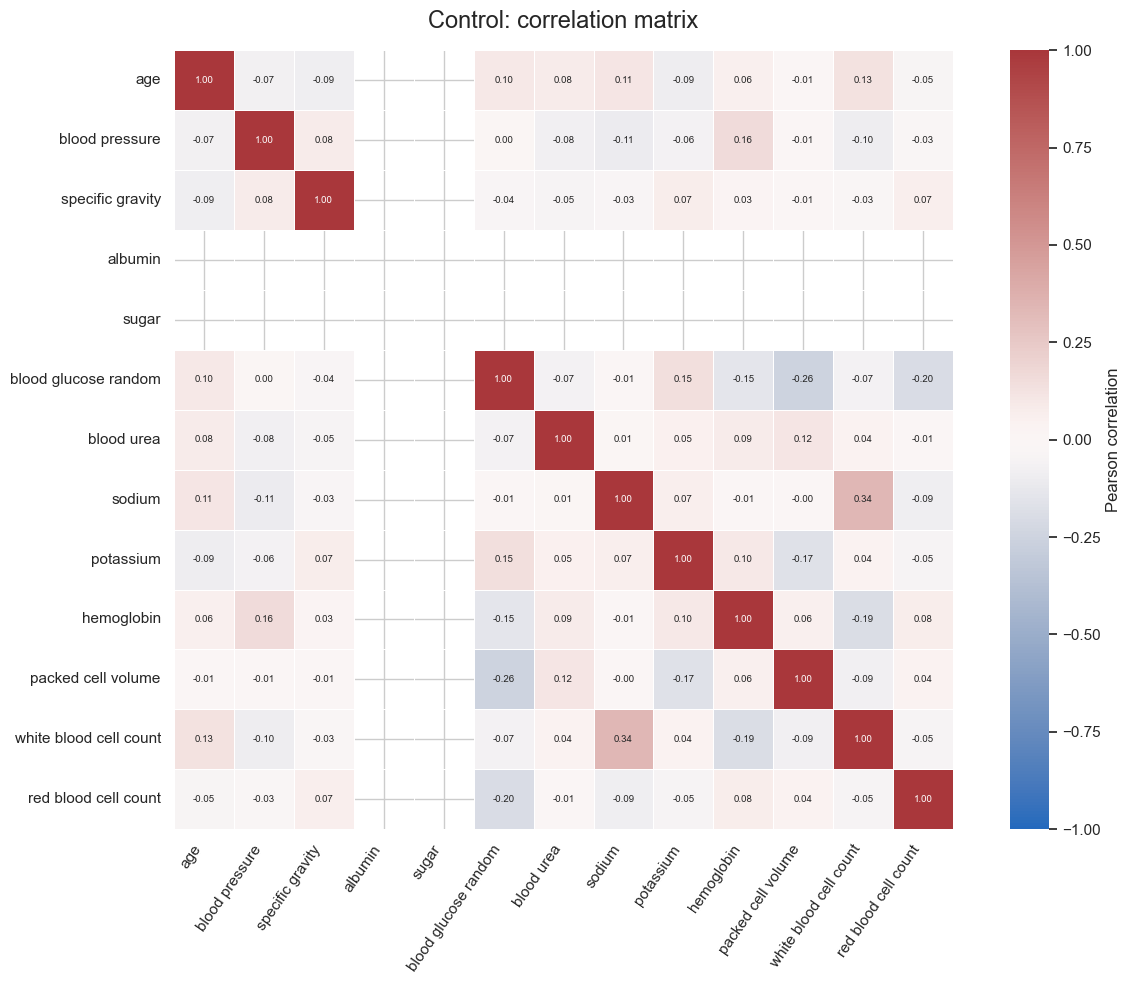

In [9]:
def plot_correlation_matrix(frame: pd.DataFrame, group_name: str) -> pd.DataFrame:
    corr = frame[NUMERIC_COLUMNS].corr(method="pearson")
    plt.figure(figsize=(13, 10))
    sns.heatmap(
        corr,
        cmap="vlag",
        vmin=-1,
        vmax=1,
        center=0,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 7},
        square=True,
        linewidths=0.4,
        cbar_kws={"label": "Pearson correlation"},
    )
    plt.title(f"{group_name}: correlation matrix", fontsize=17, pad=16)
    plt.xticks(rotation=55, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    return corr


affected_corr = plot_correlation_matrix(affected, "Affected")
control_corr = plot_correlation_matrix(control, "Control")

In [10]:
def strongest_unique_correlations(corr: pd.DataFrame, n: int = 8) -> pd.DataFrame:
    upper_triangle = np.triu(np.ones(corr.shape, dtype=bool), k=1)
    pairs = corr.where(upper_triangle).stack().rename("correlation").reset_index()
    pairs.columns = ["variable 1", "variable 2", "correlation"]
    pairs["absolute correlation"] = pairs["correlation"].abs()
    return pairs.sort_values("absolute correlation", ascending=False).head(n)


print("Affected: strongest absolute correlations")
display(strongest_unique_correlations(affected_corr))

print("Control: strongest absolute correlations")
display(strongest_unique_correlations(control_corr))

Affected: strongest absolute correlations


,variable 1,variable 2,correlation,absolute correlation
72,hemoglobin,packed cell volume,0.952,0.952
76,packed cell volume,red blood cell count,0.795,0.795
74,hemoglobin,red blood cell count,0.779,0.779
42,sugar,blood glucose random,0.692,0.692
59,blood urea,hemoglobin,-0.609,0.609
60,blood urea,packed cell volume,-0.569,0.569
62,blood urea,red blood cell count,-0.488,0.488
35,albumin,blood urea,0.427,0.427


Control: strongest absolute correlations


,variable 1,variable 2,correlation,absolute correlation
43,sodium,white blood cell count,0.338,0.338
31,blood glucose random,packed cell volume,-0.258,0.258
33,blood glucose random,red blood cell count,-0.197,0.197
50,hemoglobin,white blood cell count,-0.191,0.191
46,potassium,packed cell volume,-0.169,0.169
15,blood pressure,hemoglobin,0.158,0.158
30,blood glucose random,hemoglobin,-0.148,0.148
29,blood glucose random,potassium,0.147,0.147


### Correlation interpretation

**Affected individuals.** The strongest relationship is the positive correlation between hemoglobin and packed cell volume (about **0.95**). Red blood cell count is also strongly positively related to packed cell volume (about **0.80**) and hemoglobin (about **0.78**). These variables describe related aspects of red-cell status, so their co-movement is expected. Sugar and random blood glucose have a moderately strong positive correlation (about **0.69**). Blood urea is negatively associated with hemoglobin and packed cell volume (absolute correlations around **0.61** and **0.57**, respectively). This pattern describes co-occurring measurements within the affected sample; it does not show that one measurement causes another.

**Control individuals.** Correlations are much weaker. The largest absolute coefficient is only about **0.34** (sodium with white blood cell count), followed by random blood glucose with packed cell volume (about **−0.26**). The restricted range of relatively healthy control measurements can naturally attenuate correlations, and the sample size and remaining missingness add uncertainty.

**Comparison.** The affected group contains several pronounced clusters—especially the red-cell measurements and sugar/glucose—whereas the control heatmap is mostly near zero. Because many pairs were inspected and no uncertainty intervals or significance tests were calculated, small isolated coefficients should not be overinterpreted.

## 8. Final conclusions

- The required preprocessing pipeline produced a 14-column data frame with hemoglobin in g/L and class coded as `a`/`c`.
- Removing rows with at least three missing selected values left **265 observations**: **126 affected** and **139 control**.
- Affected individuals show broader and more skewed measurement distributions. Plausible extreme laboratory values should be retained unless source validation identifies an error.
- The affected group has strong relationships among hemoglobin, packed cell volume, and red blood cell count, plus a sugar/glucose association. The control group has no similarly strong linear relationships.
- The findings are exploratory and associational, not causal.